# Network Intrusion Detection - Model Training and Evaluation

In [16]:
import os
if 'MPLBACKEND' in os.environ:
    del os.environ['MPLBACKEND']

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
print(f"Matplotlib configured: {matplotlib.get_backend()}")

Matplotlib configured: module://matplotlib_inline.backend_inline


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

images_dir = './images'
os.makedirs(images_dir, exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


# Binary Classification

In [18]:
train_path = '../data/processed/train_data.csv'
test_path = '../data/processed/test_data.csv'
eval_path = '../data/processed/eval_data.csv'

for path in [train_path, test_path, eval_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}. Run data_analysis.ipynb first.")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
eval_df = pd.read_csv(eval_path)

print(f"Loaded: train ({len(train_df):,}), test ({len(test_df):,}), eval ({len(eval_df):,})")

Loaded: train (14,511), test (104,484), eval (26,121)


## Separate features and labels

In [19]:
X_train = train_df.drop(columns=['Label', 'Attack'])
y_train = train_df['Label'].astype(int)
X_test = test_df.drop(columns=['Label', 'Attack'])
y_test = test_df['Label'].astype(int)
X_eval = eval_df.drop(columns=['Label', 'Attack'])
y_eval = eval_df['Label'].astype(int)

print(f"Training: {X_train.shape[0]:,} samples and {X_train.shape[1]} features")
print(f"Test: {X_test.shape[0]:,} samples and {X_test.shape[1]} features")
print(f"Evaluation: {X_eval.shape[0]:,} samples and {X_eval.shape[1]} features")

print("\nLabel distribution:")
for dataset_name, y_data in [("Training", y_train), ("Test", y_test), ("Eval", y_eval)]:
    print(f"{dataset_name}:")
    for label, count in y_data.value_counts().sort_index().items():
        label_name = "Attack" if label == 1 else "Benign"
        print(f"  {label} ({label_name}): {count:,} ({count/len(y_data)*100:.1f}%)")

Training: 14,511 samples and 39 features
Test: 104,484 samples and 39 features
Evaluation: 26,121 samples and 39 features

Label distribution:
Training:
  0 (Benign): 8,707 (60.0%)
  1 (Attack): 5,804 (40.0%)
Test:
  0 (Benign): 62,690 (60.0%)
  1 (Attack): 41,794 (40.0%)
Eval:
  0 (Benign): 15,673 (60.0%)
  1 (Attack): 10,448 (40.0%)


## Initialize 8 ML models (SGD supports incremental learning with partial_fit)

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42),
    'SGD (Stochastic Gradient Descent)': SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1, class_weight='balanced')
}

print(f"{len(models)} models initialized")
for name in models.keys():
    print(f"  • {name}")

8 models initialized
  • Logistic Regression
  • Decision Tree
  • SVM
  • KNN
  • Random Forest
  • Gradient Boosting
  • AdaBoost
  • SGD (Stochastic Gradient Descent)


## Train and evaluate all 8 models


Training: Logistic Regression


/Users/andreoliveira/Documents/GitHub/Projeto-AAS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Accuracy: 0.9466, Precision: 0.9455, Recall: 0.9196, F1: 0.9324, MCC: 0.8885
  TN=15119  FP= 554  FN= 840  TP=9608
  Saved: ../Images/logistic_regression_confusion_matrix.png


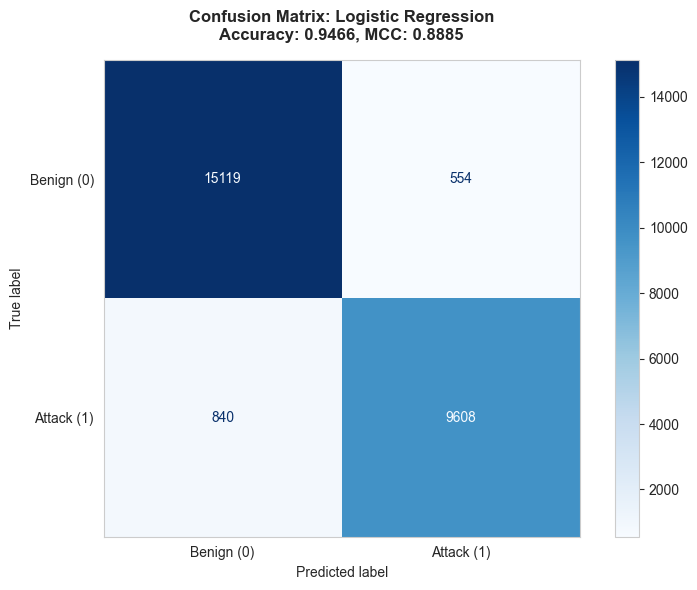


Training: Decision Tree
  Accuracy: 0.9824, Precision: 0.9783, Recall: 0.9776, F1: 0.9779, MCC: 0.9632
  TN=15446  FP= 227  FN= 234  TP=10214
  Saved: ../Images/decision_tree_confusion_matrix.png


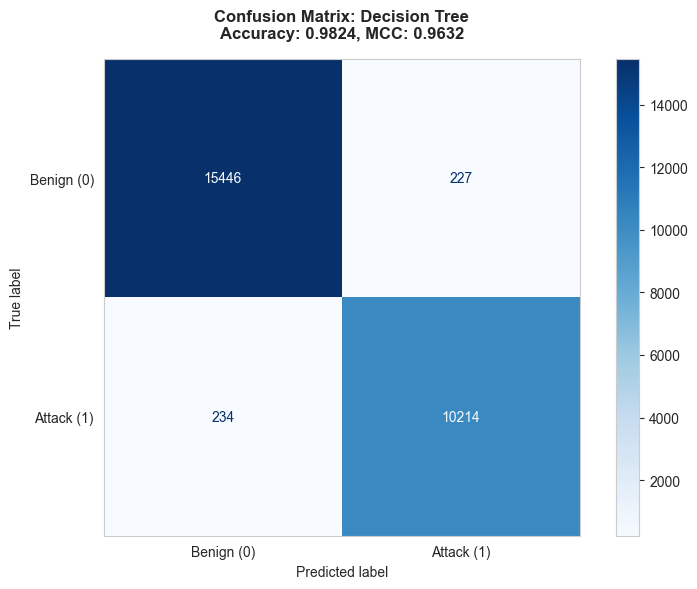


Training: SVM
  Accuracy: 0.9204, Precision: 0.8646, Recall: 0.9498, F1: 0.9052, MCC: 0.8397
  TN=14119  FP=1554  FN= 524  TP=9924
  Saved: ../Images/svm_confusion_matrix.png


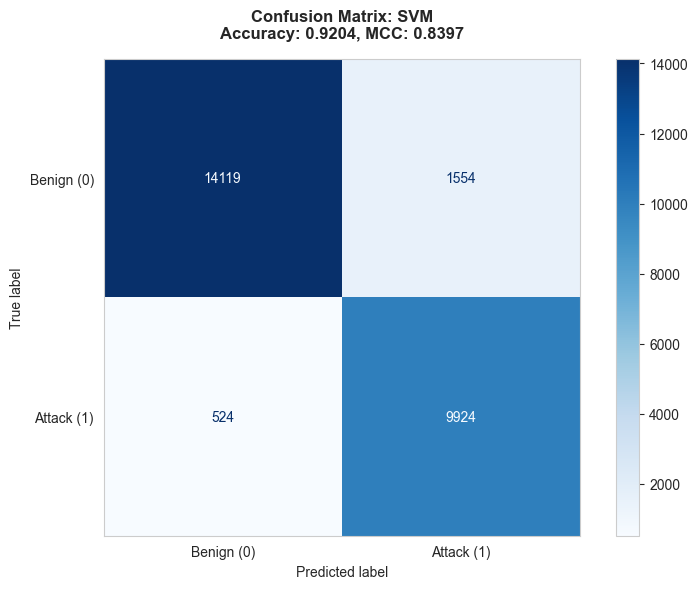


Training: KNN
  Accuracy: 0.9784, Precision: 0.9696, Recall: 0.9766, F1: 0.9731, MCC: 0.9550
  TN=15353  FP= 320  FN= 245  TP=10203
  Saved: ../Images/knn_confusion_matrix.png


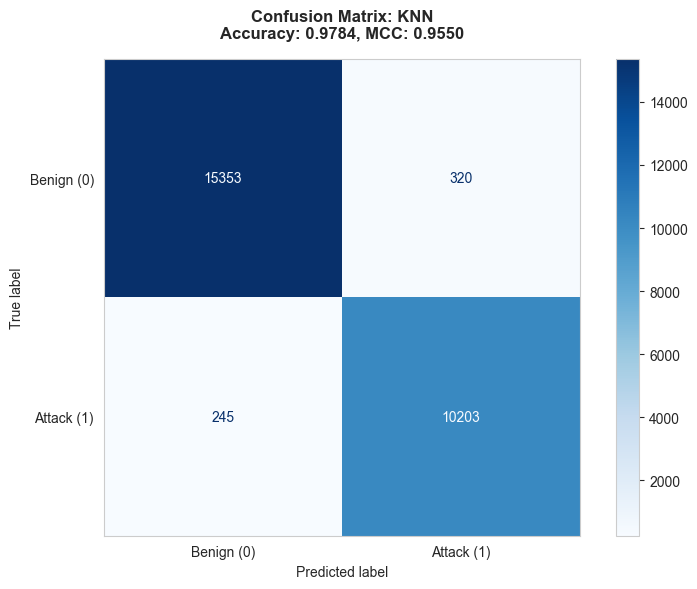


Training: Random Forest
  Accuracy: 0.9849, Precision: 0.9865, Recall: 0.9755, F1: 0.9810, MCC: 0.9685
  TN=15534  FP= 139  FN= 256  TP=10192
  Saved: ../Images/random_forest_confusion_matrix.png


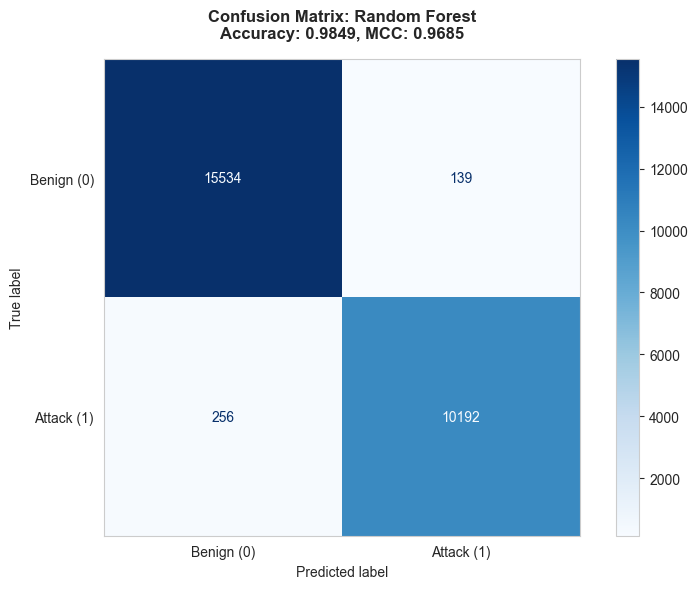


Training: Gradient Boosting
  Accuracy: 0.9855, Precision: 0.9762, Recall: 0.9878, F1: 0.9820, MCC: 0.9699
  TN=15421  FP= 252  FN= 127  TP=10321
  Saved: ../Images/gradient_boosting_confusion_matrix.png


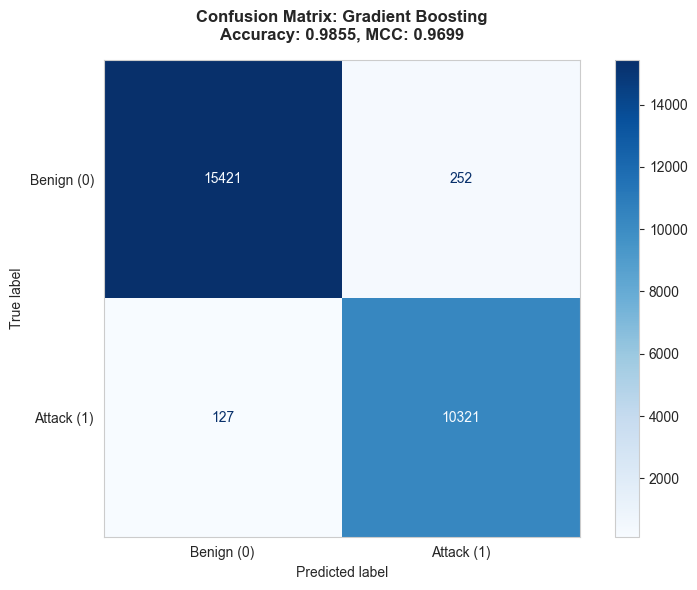


Training: AdaBoost
  Accuracy: 0.9775, Precision: 0.9711, Recall: 0.9726, F1: 0.9719, MCC: 0.9531
  TN=15371  FP= 302  FN= 286  TP=10162
  Saved: ../Images/adaboost_confusion_matrix.png


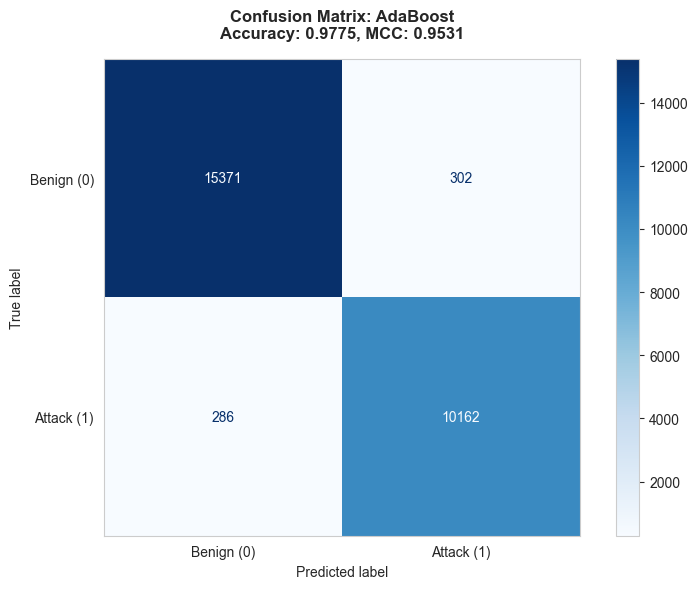


Training: SGD (Stochastic Gradient Descent)
  Accuracy: 0.8286, Precision: 0.8755, Recall: 0.6663, F1: 0.7567, MCC: 0.6422
  TN=14683  FP= 990  FN=3486  TP=6962
  Saved: ../Images/sgd_(stochastic_gradient_descent)_confusion_matrix.png


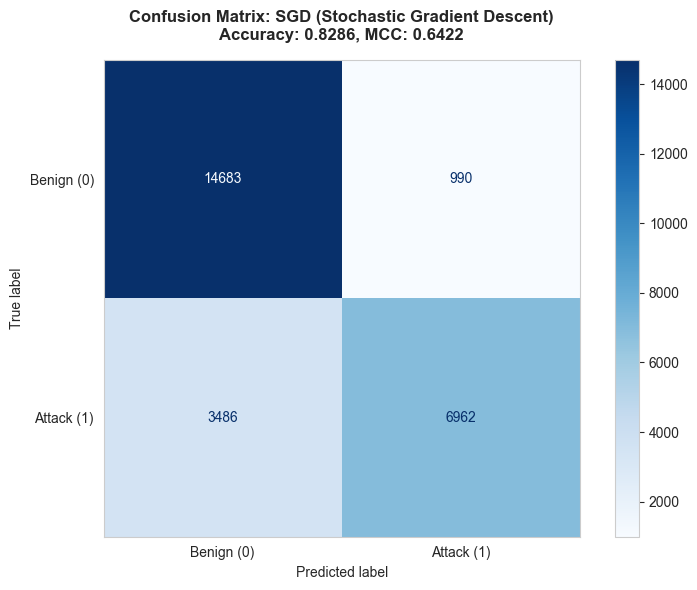


All models trained and evaluated


In [21]:
results = []

for model_name, model in models.items():
    print(f"\nTraining: {model_name}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_eval)
    
    accuracy = accuracy_score(y_eval, y_pred)
    precision = precision_score(y_eval, y_pred, zero_division=0)
    recall = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_eval, y_pred)
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'MCC': mcc,
        'TN': int(cm[0, 0]),
        'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]),
        'TP': int(cm[1, 1])
    })
    
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")
    print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Attack (1)'])
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.grid(False)
    ax.set_title(f'Confusion Matrix: {model_name}\nAccuracy: {accuracy:.4f}, MCC: {mcc:.4f}',
                fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    
    outfile = os.path.join(images_dir, f"{model_name.replace(' ', '_').lower()}_confusion_matrix.png")
    plt.savefig(outfile, dpi=150, bbox_inches='tight')
    print(f"  Saved: {outfile}")
    plt.show()

print("\nAll models trained and evaluated")

## Compare models (sorted by MCC - best metric for imbalanced data)

In [22]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MCC', ascending=False).reset_index(drop=True)

print("Model Performance Comparison (sorted by MCC):\n")

display_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']].copy()
display_df['Accuracy'] = display_df['Accuracy'].apply(lambda x: f"{x:.4f}")
display_df['Precision'] = display_df['Precision'].apply(lambda x: f"{x:.4f}")
display_df['Recall'] = display_df['Recall'].apply(lambda x: f"{x:.4f}")
display_df['F1-Score'] = display_df['F1-Score'].apply(lambda x: f"{x:.4f}")
display_df['MCC'] = display_df['MCC'].apply(lambda x: f"{x:.4f}")

display(display_df)

print("\nTop 3 Models by MCC:")
for i, row in results_df.head(3).iterrows():
    print(f"  {i+1}. {row['Model']}: MCC={row['MCC']:.4f}, Accuracy={row['Accuracy']:.4f}")

Model Performance Comparison (sorted by MCC):



,Model,Accuracy,Precision,Recall,F1-Score,MCC
0,Gradient Boosting,0.9855,0.9762,0.9878,0.9820,0.9699
1,Random Forest,0.9849,0.9865,0.9755,0.9810,0.9685
2,Decision Tree,0.9824,0.9783,0.9776,0.9779,0.9632
3,KNN,0.9784,0.9696,0.9766,0.9731,0.9550
4,AdaBoost,0.9775,0.9711,0.9726,0.9719,0.9531
5,Logistic Regression,0.9466,0.9455,0.9196,0.9324,0.8885
6,SVM,0.9204,0.8646,0.9498,0.9052,0.8397
7,SGD (Stochastic Gradient Descent),0.8286,0.8755,0.6663,0.7567,0.6422



Top 3 Models by MCC:
  1. Gradient Boosting: MCC=0.9699, Accuracy=0.9855
  2. Random Forest: MCC=0.9685, Accuracy=0.9849
  3. Decision Tree: MCC=0.9632, Accuracy=0.9824


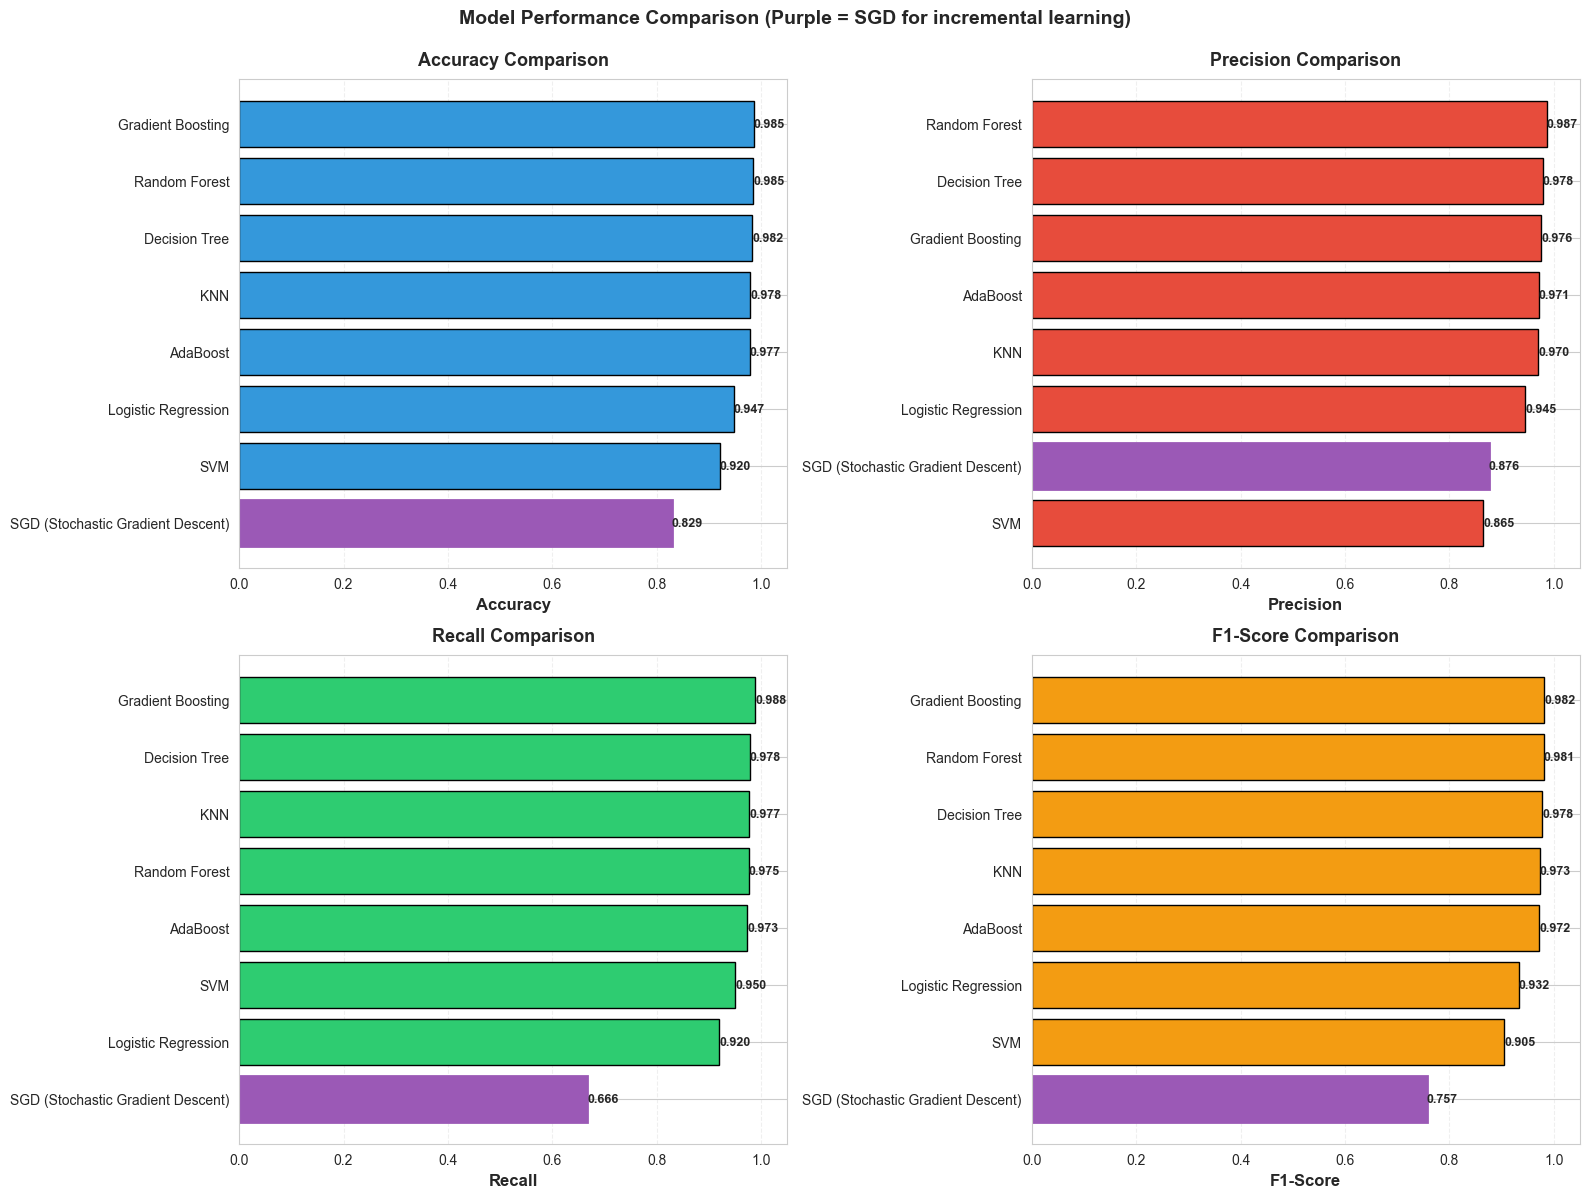

Comparison visualization saved


In [23]:
g, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]

    sorted_df = results_df.sort_values(by=metric, ascending=True)

    bars = ax.barh(
        sorted_df['Model'],
        sorted_df[metric],
        color=color,
        edgecolor='black',
        linewidth=1
    )

    for bar, model in zip(bars, sorted_df['Model']):
        if 'SGD' in str(model).upper():
            bar.set_color('#9b59b6')
            bar.set_linewidth(2)

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold', pad=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(0, 1.05)

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2.0,
            f'{width:.3f}',
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

plt.suptitle(
    'Model Performance Comparison (Purple = SGD for incremental learning)',
    fontsize=14,
    fontweight='bold',
    y=0.995
)

plt.tight_layout()

os.makedirs(images_dir, exist_ok=True)
plt.savefig(os.path.join(images_dir, 'model_comparison.png'), dpi=150, bbox_inches='tight')

plt.show()
print("Comparison visualization saved")

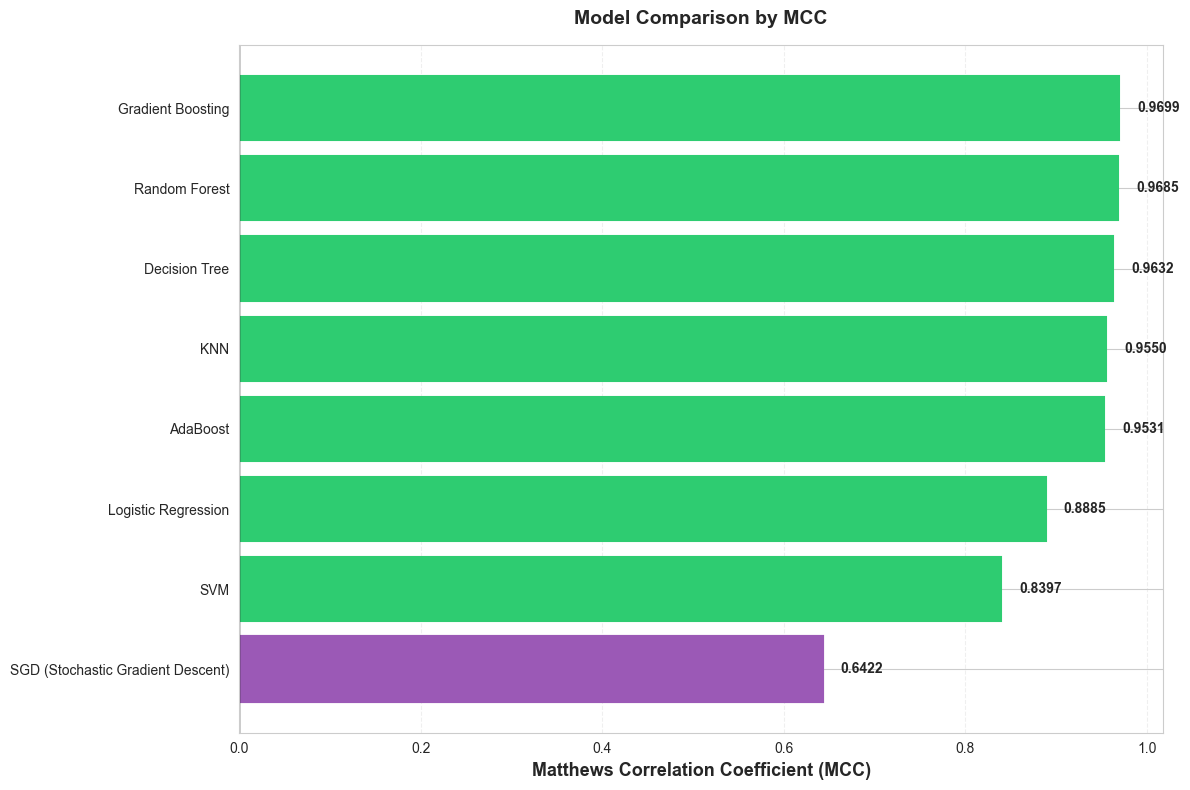

MCC comparison visualization saved


In [24]:
fig, ax = plt.subplots(figsize=(12, 8))

sorted_mcc = results_df.sort_values(by='MCC', ascending=True)

bars = ax.barh(
    sorted_mcc['Model'],
    sorted_mcc['MCC'],
    edgecolor='black',
    linewidth=1.5
)

base_colors = ['#2ecc71' if mcc > 0 else '#e74c3c' for mcc in sorted_mcc['MCC']]
for bar, c in zip(bars, base_colors):
    bar.set_color(c)

for bar, model in zip(bars, sorted_mcc['Model']):
    if 'SGD' in str(model).upper():
        bar.set_color('#9b59b6')
        bar.set_linewidth(3)

ax.set_xlabel('Matthews Correlation Coefficient (MCC)', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison by MCC', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Annotate bars
for bar in bars:
    width = bar.get_width()
    label_x = width + 0.02 if width > 0 else width - 0.02
    ha = 'left' if width > 0 else 'right'
    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2.0,
        f'{width:.4f}',
        ha=ha,
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()

os.makedirs(images_dir, exist_ok=True)
plt.savefig(os.path.join(images_dir, 'mcc_comparison.png'), dpi=150, bbox_inches='tight')

plt.show()
print("MCC comparison visualization saved")

In [25]:
sgd_model = models['SGD (Stochastic Gradient Descent)']

models_dir = '../notebooks/models'
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'sgd_model_binary.pkl')
joblib.dump(sgd_model, model_path)

print(f"SGD model saved: {model_path}")

sgd_results = results_df[results_df['Model'].str.contains('SGD')].iloc[0]
print(f"\nInitial Performance: Accuracy={sgd_results['Accuracy']:.4f}, MCC={sgd_results['MCC']:.4f}")
print("(Performance will improve with incremental learning on streaming data)")

SGD model saved: ../notebooks/models/sgd_model_binary.pkl

Initial Performance: Accuracy=0.8286, MCC=0.6422
(Performance will improve with incremental learning on streaming data)


## Detailed classification report for SGD

In [26]:
y_pred_sgd = sgd_model.predict(X_eval)

print("Detailed Classification Report (SGD Model):\n")
print(classification_report(y_eval, y_pred_sgd, target_names=['Benign (0)', 'Attack (1)'], digits=4))

cm = confusion_matrix(y_eval, y_pred_sgd, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nFalse Positive Rate: {fpr:.4f} ({fpr*100:.2f}%)")
print(f"False Negative Rate: {fnr:.4f} ({fnr*100:.2f}%)")

Detailed Classification Report (SGD Model):

              precision    recall  f1-score   support

  Benign (0)     0.8081    0.9368    0.8677     15673
  Attack (1)     0.8755    0.6663    0.7567     10448

    accuracy                         0.8286     26121
   macro avg     0.8418    0.8016    0.8122     26121
weighted avg     0.8351    0.8286    0.8233     26121


False Positive Rate: 0.0632 (6.32%)
False Negative Rate: 0.3337 (33.37%)


## Binary classification summary

In [27]:
print(f"\nModels evaluated: {len(models)}")
print(f"Dataset: {len(X_train):,} training, {len(X_eval):,} evaluation samples")

print("\nTop 3 Models by MCC:")
for i, row in results_df.head(3).iterrows():
    print(f"  {i+1}. {row['Model']}: MCC={row['MCC']:.4f}, Accuracy={row['Accuracy']:.4f}")

print(f"\nSelected: SGD (Stochastic Gradient Descent)")
sgd_row = results_df[results_df['Model'].str.contains('SGD')].iloc[0]
print(f"  Initial: Accuracy={sgd_row['Accuracy']:.4f}, MCC={sgd_row['MCC']:.4f}")
print(f"  Reason: Supports partial_fit() for incremental learning")

print(f"\nOutput: {model_path}")
print("Next: Use in streaming pipeline with incremental learning")
print("="*80)


Models evaluated: 8
Dataset: 14,511 training, 26,121 evaluation samples

Top 3 Models by MCC:
  1. Gradient Boosting: MCC=0.9699, Accuracy=0.9855
  2. Random Forest: MCC=0.9685, Accuracy=0.9849
  3. Decision Tree: MCC=0.9632, Accuracy=0.9824

Selected: SGD (Stochastic Gradient Descent)
  Initial: Accuracy=0.8286, MCC=0.6422
  Reason: Supports partial_fit() for incremental learning

Output: ../notebooks/models/sgd_model_binary.pkl
Next: Use in streaming pipeline with incremental learning


# MULTI-CLASS ATTACK TYPE CLASSIFICATION

In [28]:
train_path = '../data/processed/train_data.csv'
test_path = '../data/processed/test_data.csv'
eval_path = '../data/processed/eval_data.csv'

for path in [train_path, test_path, eval_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}. Run data_analysis.ipynb first.")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
eval_df = pd.read_csv(eval_path)

print(f"Loaded: train ({len(train_df):,}), test ({len(test_df):,}), eval ({len(eval_df):,})")

Loaded: train (14,511), test (104,484), eval (26,121)


## Separate features and labels

In [30]:
X_train = train_df.drop(columns=['Label', 'Attack'])
y_train = train_df['Attack'].astype(str)
X_test = test_df.drop(columns=['Label', 'Attack'])
y_test = test_df['Attack'].astype(str)
X_eval = eval_df.drop(columns=['Label', 'Attack'])
y_eval = eval_df['Attack'].astype(str)
attack_types = sorted(y_train.unique())

print(f"Training: {X_train.shape[0]:,} samples and {X_train.shape[1]} features")
print(f"Test: {X_test.shape[0]:,} samples and {X_test.shape[1]} features")
print(f"Evaluation: {X_eval.shape[0]:,} samples and {X_eval.shape[1]} features")
print(f"Attack types: {attack_types}")

print("\nLabel distribution:")
for dataset_name, y_data in [("Training", y_train), ("Test", y_test), ("Eval", y_eval)]:
    print(f"{dataset_name}:")
    for label, count in y_data.value_counts().sort_index().items():
        label_name = "Attack" if label == 1 else "Benign"
        print(f"  {label} ({label_name}): {count:,} ({count/len(y_data)*100:.1f}%)")

Training: 14,511 samples and 39 features
Test: 104,484 samples and 39 features
Evaluation: 26,121 samples and 39 features
Attack types: ['Benign', 'Bot', 'DDOS_attack-HOIC', 'DDoS_attacks-LOIC-HTTP', 'DoS_attacks-SlowHTTPTest', 'FTP-BruteForce', 'Infilteration', 'SSH-Bruteforce']

Label distribution:
Training:
  Benign (Benign): 8,707 (60.0%)
  Bot (Benign): 479 (3.3%)
  DDOS_attack-HOIC (Benign): 2,536 (17.5%)
  DDoS_attacks-LOIC-HTTP (Benign): 658 (4.5%)
  DoS_attacks-SlowHTTPTest (Benign): 271 (1.9%)
  FTP-BruteForce (Benign): 943 (6.5%)
  Infilteration (Benign): 476 (3.3%)
  SSH-Bruteforce (Benign): 441 (3.0%)
Test:
  Benign (Benign): 62,690 (60.0%)
  Bot (Benign): 3,651 (3.5%)
  DDOS_attack-HOIC (Benign): 17,873 (17.1%)
  DDoS_attacks-LOIC-HTTP (Benign): 5,045 (4.8%)
  DoS_attacks-SlowHTTPTest (Benign): 1,880 (1.8%)
  FTP-BruteForce (Benign): 6,765 (6.5%)
  Infilteration (Benign): 3,281 (3.1%)
  SSH-Bruteforce (Benign): 3,299 (3.2%)
Eval:
  Benign (Benign): 15,673 (60.0%)
  Bot (B

## Train multi-class classifiers

In [33]:
models_mc = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'SGD Classifier': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, n_jobs=-1),
}

results_mc = []
trained_models_mc = {}

for name, model in models_mc.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_eval)
    
    accuracy = accuracy_score(y_eval, y_pred)
    precision = precision_score(y_eval, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_eval, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_eval, y_pred, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(y_eval, y_pred)
    
    results_mc.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'MCC': mcc
    })
    
    trained_models_mc[name] = model
    print(f"  Accuracy: {accuracy:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")

results_mc_df = pd.DataFrame(results_mc)
results_mc_df = results_mc_df.sort_values('MCC', ascending=False).reset_index(drop=True)

print("\nMulti-Class Model Comparison:")
display(results_mc_df)

Training Random Forest...
  Accuracy: 0.9856, F1: 0.9851, MCC: 0.9760
Training Decision Tree...
  Accuracy: 0.9729, F1: 0.9744, MCC: 0.9554
Training Gradient Boosting...
  Accuracy: 0.9823, F1: 0.9826, MCC: 0.9706
Training Logistic Regression...


/Users/andreoliveira/Documents/GitHub/Projeto-AAS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Accuracy: 0.9081, F1: 0.9004, MCC: 0.8543
Training SGD Classifier...
  Accuracy: 0.7548, F1: 0.7243, MCC: 0.6139

Multi-Class Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,MCC
0,Random Forest,0.985644,0.984914,0.985644,0.985120,0.976035
1,Gradient Boosting,0.982275,0.983109,0.982275,0.982641,0.970588
2,Decision Tree,0.972857,0.976836,0.972857,0.974449,0.955429
3,Logistic Regression,0.908120,0.906660,0.908120,0.900394,0.854292
4,SGD Classifier,0.754795,0.727371,0.754795,0.724345,0.613882


## Evaluate best multi-class model


Best Model: Random Forest

Classification Report:
                          precision    recall  f1-score   support

                  Benign       0.98      0.99      0.99     15673
                     Bot       1.00      1.00      1.00       946
        DDOS_attack-HOIC       1.00      1.00      1.00      4483
  DDoS_attacks-LOIC-HTTP       1.00      1.00      1.00      1200
DoS_attacks-SlowHTTPTest       1.00      1.00      1.00       434
          FTP-BruteForce       1.00      1.00      1.00      1680
           Infilteration       0.83      0.71      0.77       861
          SSH-Bruteforce       1.00      1.00      1.00       844

                accuracy                           0.99     26121
               macro avg       0.98      0.96      0.97     26121
            weighted avg       0.98      0.99      0.99     26121



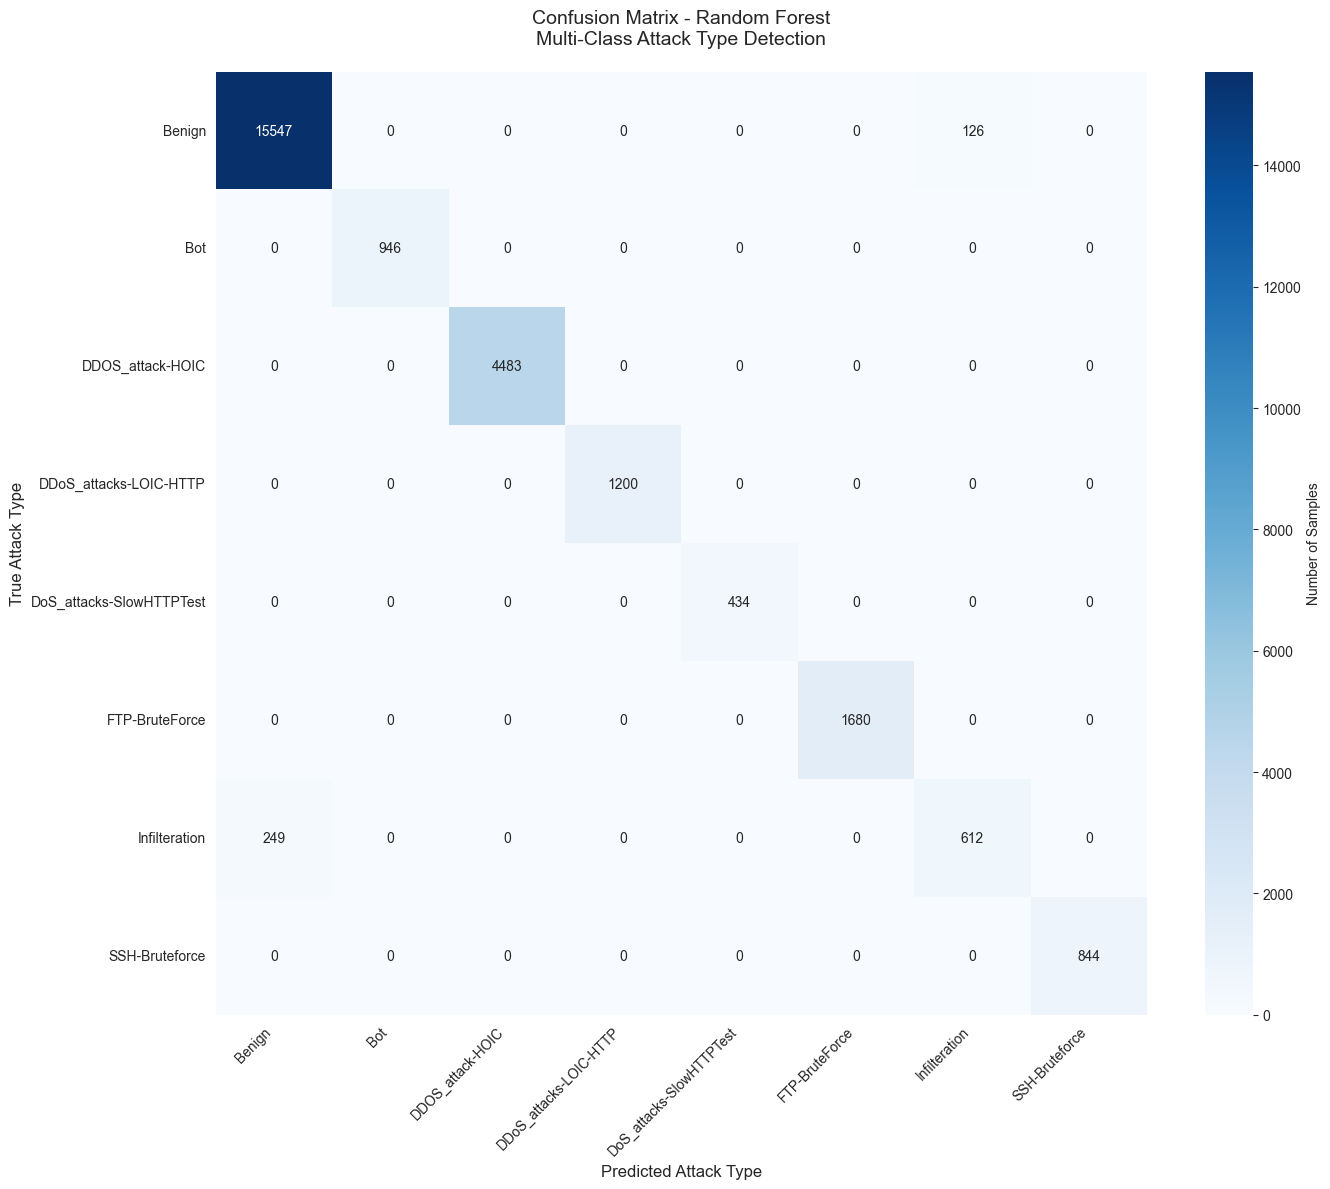

Saved: ../Images/confusion_matrix_multiclass_random_forest.png


In [34]:
best_model_name_mc = results_mc_df.iloc[0]['Model']
best_model_mc = trained_models_mc[best_model_name_mc]

print(f"\nBest Model: {best_model_name_mc}")

y_pred = best_model_mc.predict(X_eval)

print("\nClassification Report:")
print(classification_report(y_eval, y_pred, target_names=attack_types, zero_division=0))

cm_mc = confusion_matrix(y_eval, y_pred, labels=attack_types)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=attack_types, yticklabels=attack_types,
            cbar_kws={'label': 'Number of Samples'})
plt.title(f'Confusion Matrix - {best_model_name_mc}\nMulti-Class Attack Type Detection', 
          fontsize=14, pad=20)
plt.ylabel('True Attack Type', fontsize=12)
plt.xlabel('Predicted Attack Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{images_dir}/confusion_matrix_multiclass_{best_model_name_mc.replace(" ", "_").lower()}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {images_dir}/confusion_matrix_multiclass_{best_model_name_mc.replace(' ', '_').lower()}.png")

## Visualize multi-class model comparison

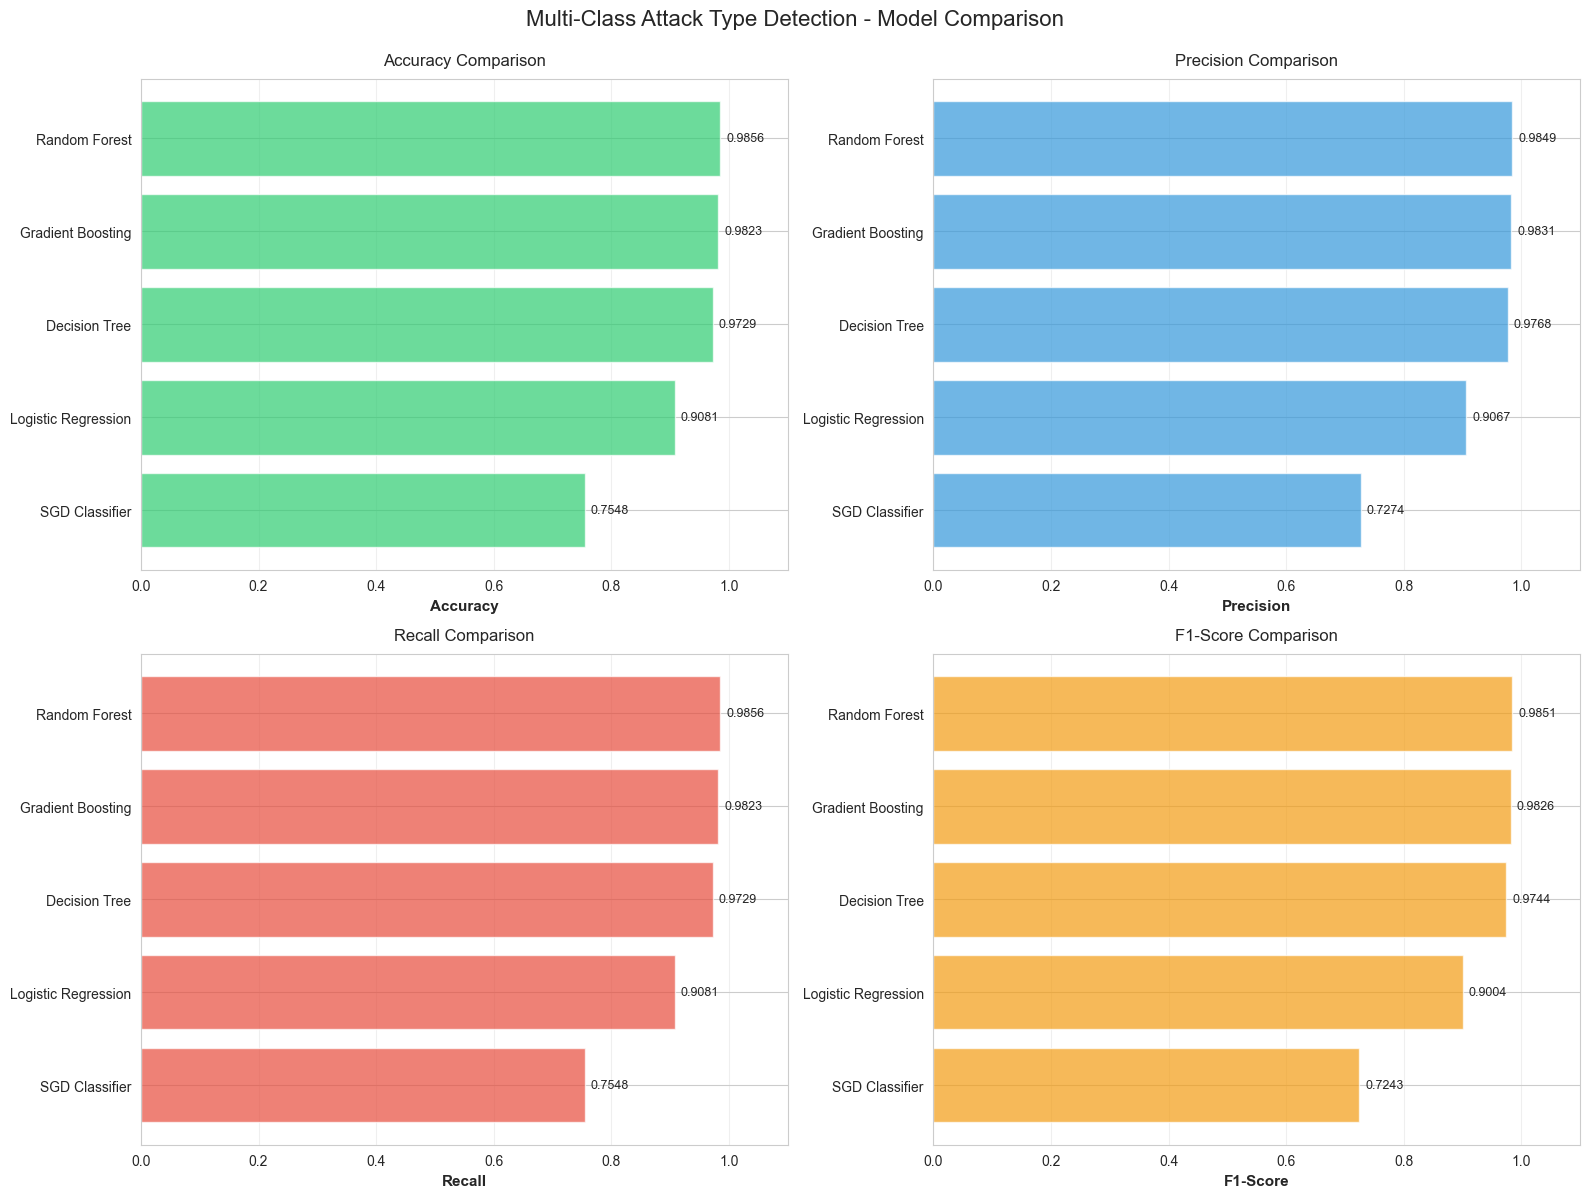

Saved: ../Images/model_comparison_multiclass.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-Class Attack Type Detection - Model Comparison', fontsize=16, y=0.995)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    sorted_df = results_mc_df.sort_values(metric, ascending=True)
    
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.7)
    
    for i, (bar, value) in enumerate(zip(bars, sorted_df[metric])):
        ax.text(value + 0.01, i, f'{value:.4f}', va='center', ha='left', fontsize=9)
    
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.grid(axis='x', alpha=0.3)
    ax.set_title(f'{metric} Comparison', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(f'{images_dir}/model_comparison_multiclass.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {images_dir}/model_comparison_multiclass.png")

## Save best multi-class model

In [36]:
model_mc_path = f'../notebooks/models/{best_model_name_mc.replace(" ", "_").lower()}_multiclass.pkl'
joblib.dump(best_model_mc, model_mc_path)
print(f"Best model saved: {model_mc_path}")

Best model saved: ../notebooks/models/random_forest_multiclass.pkl


## Analyze per-attack type performance


Per-Attack Type Performance:
             Attack Type  True Samples  Predicted  Precision   Recall  F1-Score  Accuracy
                     Bot           946        946   1.000000 1.000000  1.000000  1.000000
        DDOS_attack-HOIC          4483       4483   1.000000 1.000000  1.000000  1.000000
  DDoS_attacks-LOIC-HTTP          1200       1200   1.000000 1.000000  1.000000  1.000000
DoS_attacks-SlowHTTPTest           434        434   1.000000 1.000000  1.000000  1.000000
          FTP-BruteForce          1680       1680   1.000000 1.000000  1.000000  1.000000
          SSH-Bruteforce           844        844   1.000000 1.000000  1.000000  1.000000
                  Benign         15673      15796   0.984237 0.991961  0.988084  0.985644
           Infilteration           861        738   0.829268 0.710801  0.765478  0.985644


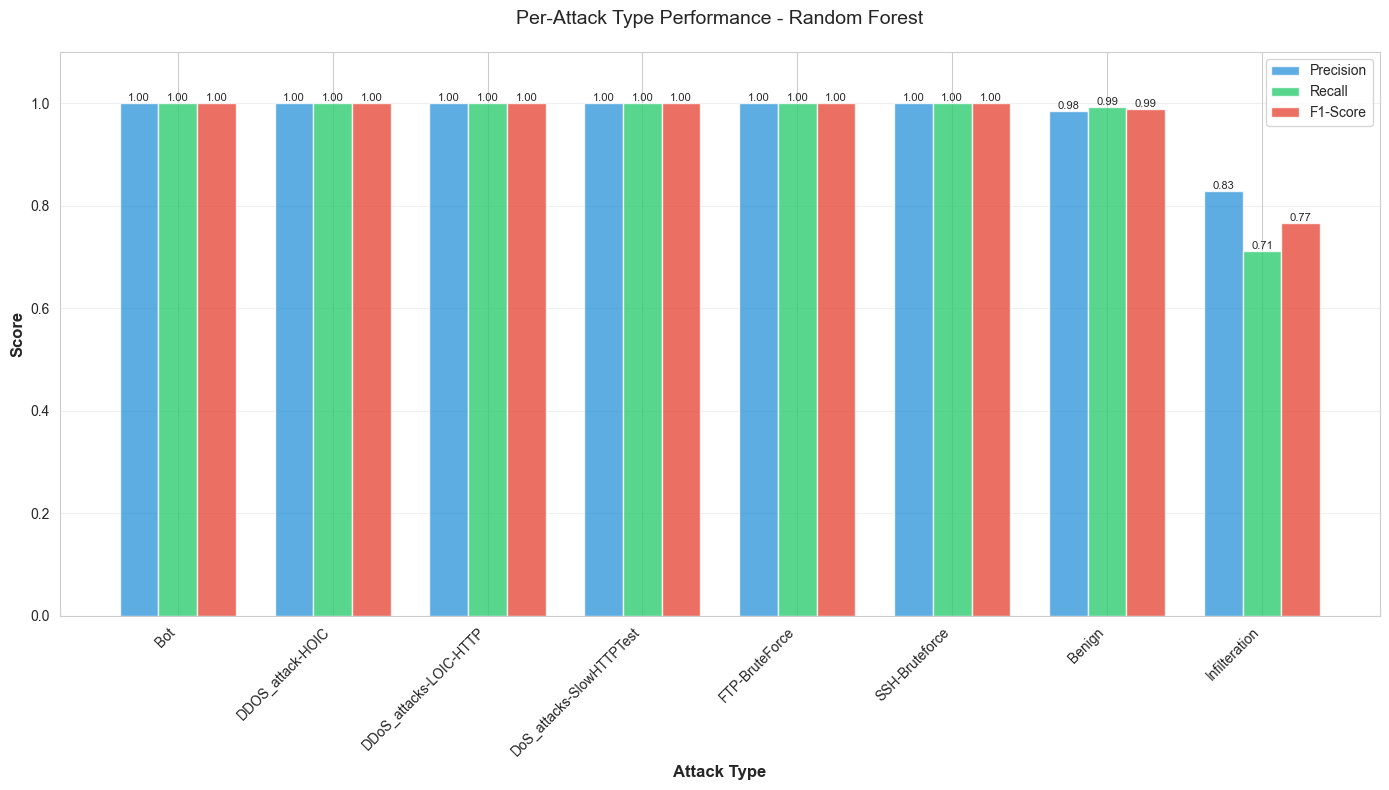

Saved: ../Images/per_attack_performance_multiclass.png


In [37]:
per_class_metrics = []

for attack in attack_types:
    y_true_binary = (y_eval == attack).astype(int)
    y_pred_binary = (y_pred == attack).astype(int)
    
    acc = accuracy_score(y_true_binary, y_pred_binary)
    prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    rec = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    
    per_class_metrics.append({
        'Attack Type': attack,
        'True Samples': y_true_binary.sum(),
        'Predicted': y_pred_binary.sum(),
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Accuracy': acc
    })

per_class_df = pd.DataFrame(per_class_metrics).sort_values('F1-Score', ascending=False)
print("\nPer-Attack Type Performance:")
print(per_class_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(attack_types))
width = 0.25
sorted_df = per_class_df.sort_values('F1-Score', ascending=False)

bars1 = ax.bar(x - width, sorted_df['Precision'], width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, sorted_df['Recall'], width, label='Recall', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, sorted_df['F1-Score'], width, label='F1-Score', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Per-Attack Type Performance - {best_model_name_mc}', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(sorted_df['Attack Type'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{images_dir}/per_attack_performance_multiclass.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {images_dir}/per_attack_performance_multiclass.png")

## Multi-class classification summary

In [38]:
print(f"\nModels evaluated: {len(models_mc)}")
print(f"Dataset: {len(X_train):,} training, {len(X_eval):,} evaluation samples")
print(f"Classes: {len(attack_types)}")

print("\nTop 3 Models by MCC:")
for i, row in results_mc_df.head(3).iterrows():
    print(f"  {i+1}. {row['Model']}: MCC={row['MCC']:.4f}, Accuracy={row['Accuracy']:.4f}")

print(f"\nBest Model: {best_model_name_mc}")
best_row_mc = results_mc_df.iloc[0]
print(f"  Accuracy: {best_row_mc['Accuracy']:.4f}, F1: {best_row_mc['F1-Score']:.4f}, MCC: {best_row_mc['MCC']:.4f}")


Models evaluated: 5
Dataset: 14,511 training, 26,121 evaluation samples
Classes: 8

Top 3 Models by MCC:
  1. Random Forest: MCC=0.9760, Accuracy=0.9856
  2. Gradient Boosting: MCC=0.9706, Accuracy=0.9823
  3. Decision Tree: MCC=0.9554, Accuracy=0.9729

Best Model: Random Forest
  Accuracy: 0.9856, F1: 0.9851, MCC: 0.9760
